In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.constants import *
from utils.paths import *
from utils.plotting import *
from utils.analysis import *
from tqdm import tqdm
from matplotlib import rcParams

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

In [2]:
prefix_list = ['20231113_3', '20240311', '20240316']
clist = ['#1f77b4', '#ff7f0e', '#2ca02c']
outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

data_collection = {}
for prefix in prefix_list:
    temp_data = pd.read_csv(os.path.join(outdir, prefix, 'analysis_ts.csv'),
                            header = [0, 1, 2, 3], index_col = 0, parse_dates=True)
    # average hummock and hollow; resample to annual
    temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36)
    temp_data.columns = temp_data.columns.reorder_levels(['variable', 'pft', 'plot'])
    # focus on ambient plots only
    filt = [chamber_levels_complete[f'{int(c):02d}'][1] == 0 \
            for c in temp_data.columns.get_level_values(2)]
    temp_data = temp_data.loc[:, filt]
    data_collection[prefix] = temp_data.groupby(temp_data.index.month
        ).mean().sort_index(axis = 1).stack()

/tmp/ipykernel_1875746/817387537.py:10: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_1875746/817387537.py:10: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_1875746/817387537.py:10: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1


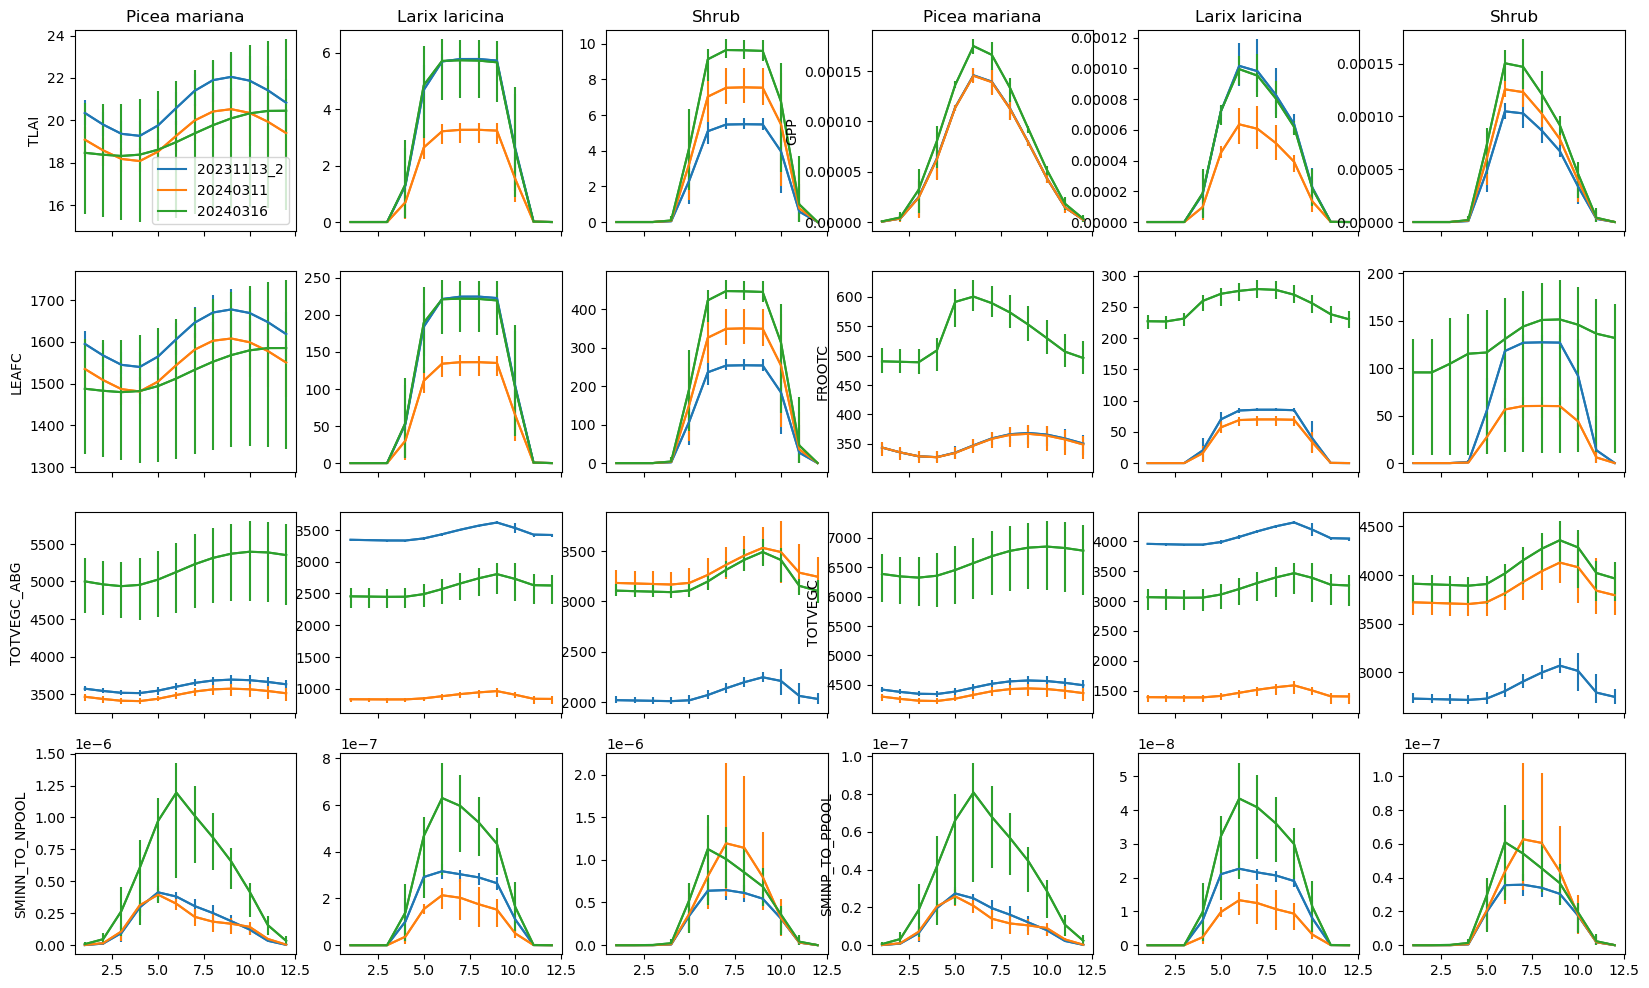

In [3]:
var_list = ['TLAI', 'GPP', 'LEAFC', 'FROOTC', 'TOTVEGC_ABG', 'TOTVEGC', 
            'SMINN_TO_NPOOL', 'SMINP_TO_PPOOL']
pft_list = [2, 3, 11]
pft_names = ['Picea mariana', 'Larix laricina', 'Shrub']

fig, axes = plt.subplots(int(np.ceil(len(var_list) / 2)), len(pft_list) * 2,
                             figsize = (20, 12), sharex = True)

for i, var in enumerate(var_list):
    for j, (pft, pft_name) in enumerate(zip(pft_list, pft_names)):
        ax = axes[int(np.floor(i/2)), j + len(pft_list) * np.mod(i, 2)]

        for prefix, color in zip(prefix_list, clist):
            temp = data_collection[prefix].loc[:, (var, str(pft))].unstack()
            temp_mean = temp.mean(axis = 1)
            temp_min = temp.min(axis = 1)
            temp_max = temp.max(axis = 1)
            ax.plot(range(1, 13), temp_mean, '-', color = color, label = prefix)
            ax.errorbar(range(1, 13), temp_mean, 
                        yerr = np.vstack([(temp_mean - temp_min).clip(lower = 0),
                                          (temp_max - temp_mean).clip(lower = 0)]), 
                        ls = '-', color = color)

        if i < 2:
            ax.set_title(pft_name)
        if j == 0:
            ax.set_ylabel(var)
            if i == 0:
                ax.legend()

plt.savefig(os.path.join(path_out, f'plot_carbon_cycle_compare_seasonality.png'), 
            dpi = 600., bbox_inches = 'tight')

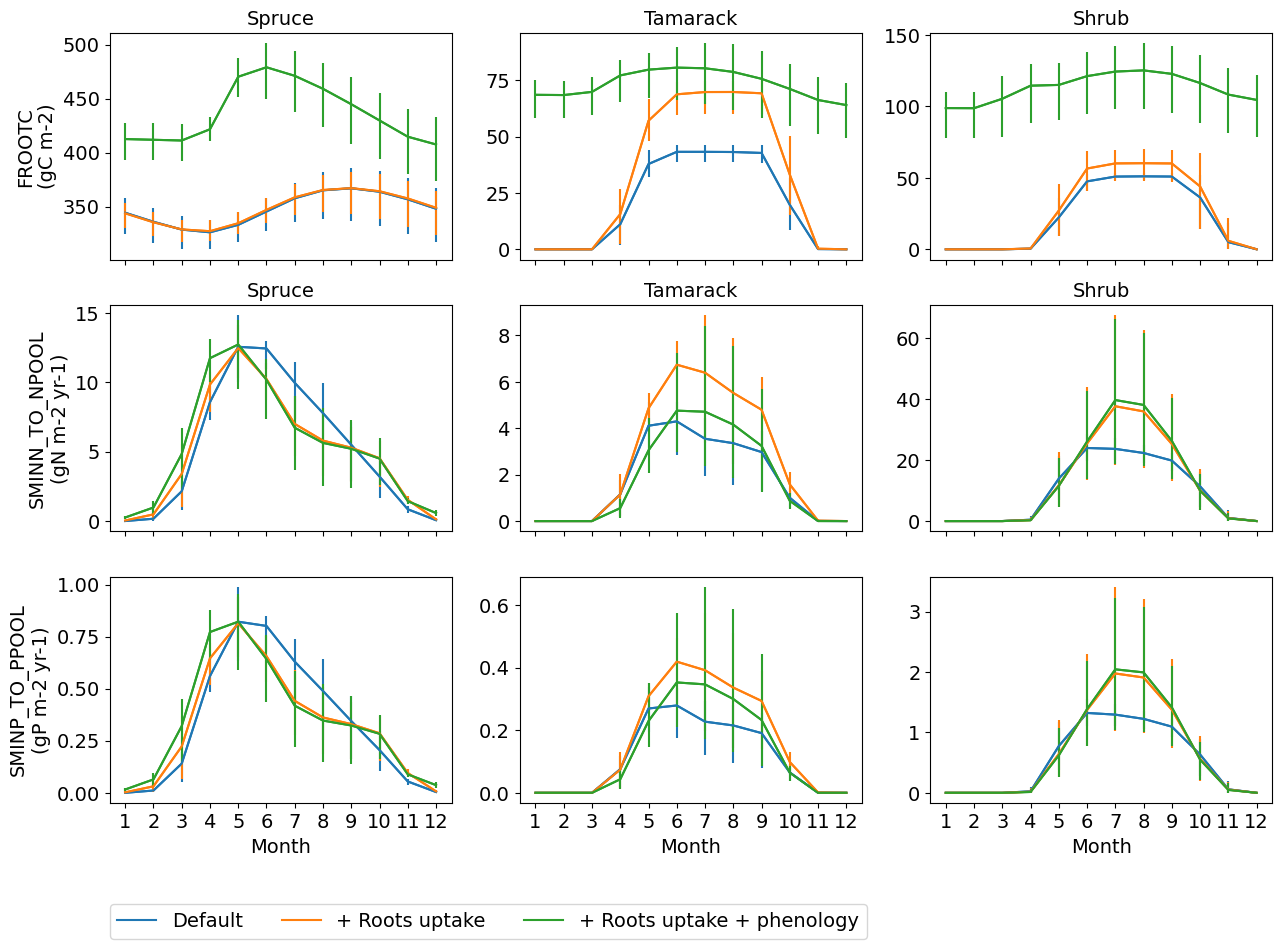

In [6]:
var_list = ['FROOTC', 'SMINN_TO_NPOOL', 'SMINP_TO_PPOOL']
unit_list = ['gC m-2', 'gN m-2 yr-1', 'gP m-2 yr-1']
prefix_names = ['Default', '+ Roots uptake', '+ Roots uptake + phenology']
pft_list = [2, 3, 11]
pft_names = ['Spruce', 'Tamarack', 'Shrub']

fig, axes = plt.subplots(3, 3, figsize = (15, 10), sharex = True)

for i, (var, unit) in enumerate(zip(var_list, unit_list)):
    for j, (pft, pft_name) in enumerate(zip(pft_list, pft_names)):
        ax = axes[i,j]

        for prefix, prefix_name, color in zip(prefix_list, prefix_names, clist):
            temp = data_collection[prefix].loc[:, (var, str(pft))].unstack()
            if var != 'FROOTC':
                temp = temp * 365 * 86400

            temp_mean = temp.mean(axis = 1)
            temp_min = temp.min(axis = 1)
            temp_max = temp.max(axis = 1)
            ax.plot(range(1, 13), temp_mean, '-', color = color, label = prefix_name)
            ax.errorbar(range(1, 13), temp_mean, 
                        yerr = np.vstack([(temp_mean - temp_min).clip(lower = 0),
                                          (temp_max - temp_mean).clip(lower = 0)]), 
                        ls = '-', color = color)

        if i < 2:
            ax.set_title(pft_name)
        if j == 0:
            ax.set_ylabel(f'{var}\n({unit})')
            if i == 0:
                ax.legend(loc = (0, -3), ncol = 4)
        ax.set_xticks(range(1,13))
        if i == 2:
            ax.set_xlabel('Month')

plt.savefig(os.path.join(path_out, f'plot_carbon_cycle_compare_seasonality.png'), 
            dpi = 600., bbox_inches = 'tight')

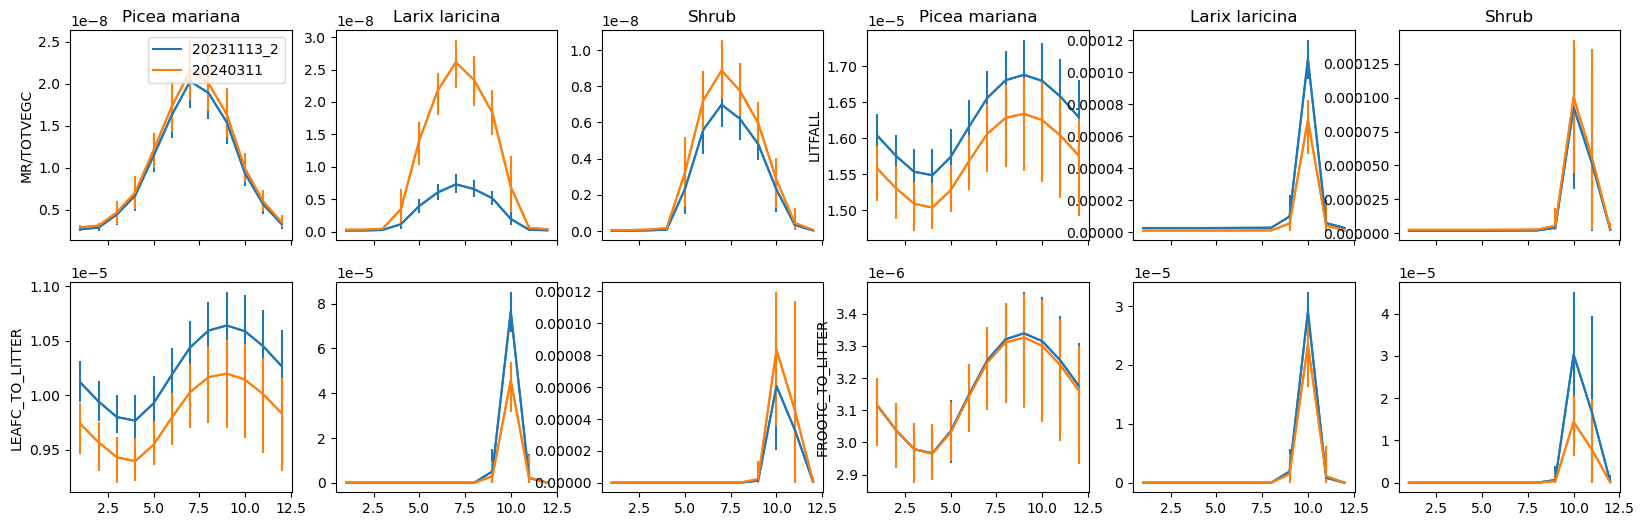

In [4]:
# Turnover variables in a separate graph

var_list = ['MR/TOTVEGC', 'LITFALL', 'LEAFC_TO_LITTER', 'FROOTC_TO_LITTER']
pft_list = [2, 3, 11]
pft_names = ['Picea mariana', 'Larix laricina', 'Shrub']

fig, axes = plt.subplots(int(np.ceil(len(var_list) / 2)), len(pft_list) * 2,
                         figsize = (20, 6), sharex = True)

for i, var in enumerate(var_list):
    for j, (pft, pft_name) in enumerate(zip(pft_list, pft_names)):
        ax = axes[int(np.floor(i/2)), j + len(pft_list) * np.mod(i, 2)]

        for prefix, color in zip(prefix_list, clist):
            if var == 'MR/TOTVEGC':
                temp = (data_collection[prefix].loc[:, ('MR', str(pft))] / \
                    data_collection[prefix].loc[:, ('TOTVEGC', str(pft))].values).unstack()
            else:
                temp = data_collection[prefix].loc[:, (var, str(pft))].unstack()
            temp_mean = temp.mean(axis = 1)
            temp_min = temp.min(axis = 1)
            temp_max = temp.max(axis = 1)
            ax.plot(range(1, 13), temp_mean, '-', color = color, label = prefix)
            ax.errorbar(range(1, 13), temp_mean, 
                        yerr = np.vstack([(temp_mean - temp_min).clip(lower = 0),
                                          (temp_max - temp_mean).clip(lower = 0)]), 
                        ls = '-', color = color)

        if i < 2:
            ax.set_title(pft_name)
        if j == 0:
            ax.set_ylabel(var)
            if i == 0:
                ax.legend()

plt.savefig(os.path.join(path_out, f'plot_carbon_cycle_compare_seasonality2.png'), 
            dpi = 600., bbox_inches = 'tight')

IndexError: index 6 is out of bounds for axis 0 with size 6

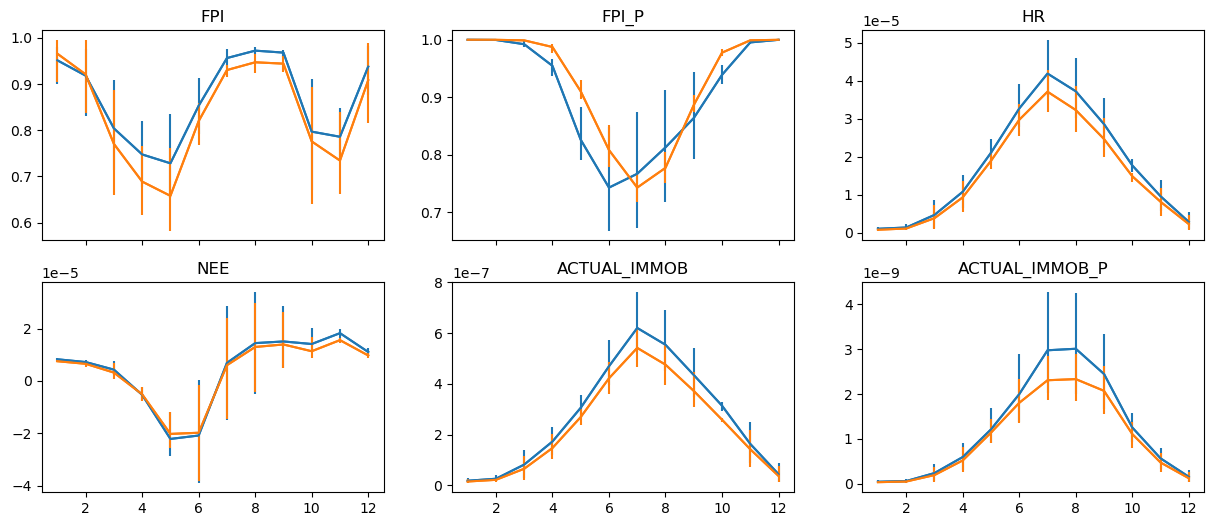

In [5]:
var_list = ['FPI', 'FPI_P', 'HR', 'NEE', 'ACTUAL_IMMOB', 'ACTUAL_IMMOB_P']

fig, axes = plt.subplots(2, 3, figsize = (15, 6), sharex = True)
#fig, axes = plt.subplots(2, 2, figsize = (10, 6), sharex = True)

for i, var in enumerate(var_list):
    ax = axes.flat[i]

    for prefix, color in zip(prefix_list, clist):

        temp = data_collection[prefix].loc[:, (var, '0')].unstack()

        temp_mean = temp.mean(axis = 1)
        temp_min = temp.min(axis = 1)
        temp_max = temp.max(axis = 1)

        ax.plot(range(1, 13), temp_mean, '-', color = color, label = prefix)
        ax.errorbar(range(1, 13), temp_mean, 
                    yerr = np.vstack([(temp_mean - temp_min).clip(lower = 0),
                                      (temp_max - temp_mean).clip(lower = 0)]), 
                    ls = '-', color = color)

    ax.set_title(var)
    if i == len(var_list) - 1:
        ax.legend()

plt.savefig(os.path.join(path_out, f'plot_carbon_cycle_compare_seasonality3.png'), 
            dpi = 600., bbox_inches = 'tight')

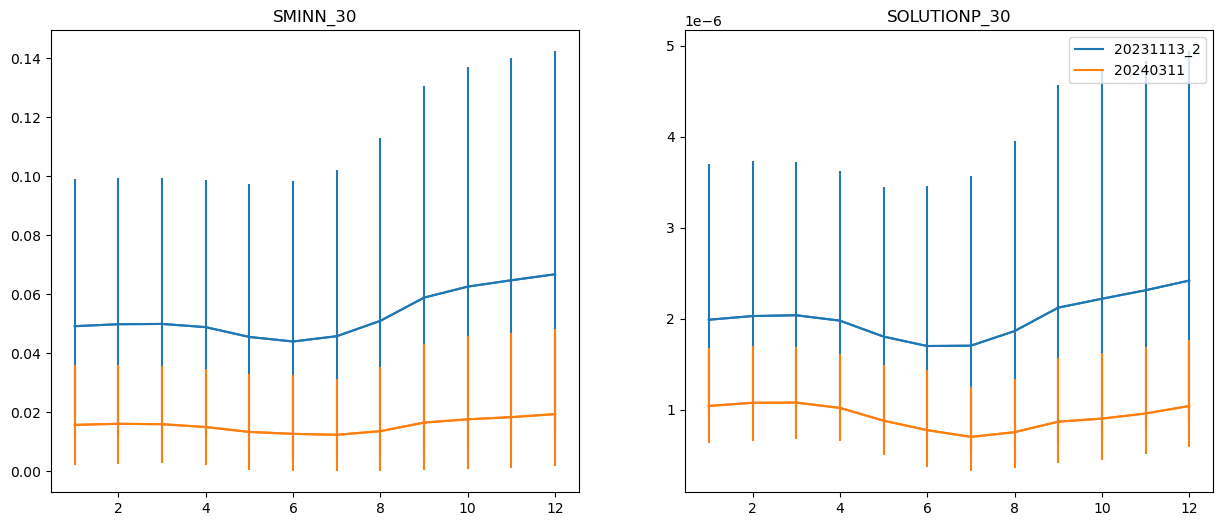

In [7]:
var_list = ['SMINN_30','SOLUTIONP_30']

fig, axes = plt.subplots(1, 2, figsize = (15, 6), sharex = True)
#fig, axes = plt.subplots(2, 2, figsize = (10, 6), sharex = True)

for i, var in enumerate(var_list):
    ax = axes.flat[i]

    for prefix, color in zip(prefix_list, clist):

        temp = data_collection[prefix].loc[:, (var, '0')].unstack()

        temp_mean = temp.mean(axis = 1)
        temp_min = temp.min(axis = 1)
        temp_max = temp.max(axis = 1)

        ax.plot(range(1, 13), temp_mean, '-', color = color, label = prefix)
        ax.errorbar(range(1, 13), temp_mean, 
                    yerr = np.vstack([(temp_mean - temp_min).clip(lower = 0),
                                      (temp_max - temp_mean).clip(lower = 0)]), 
                    ls = '-', color = color)

    ax.set_title(var)
    if i == len(var_list) - 1:
        ax.legend()

plt.savefig(os.path.join(path_out, f'plot_carbon_cycle_compare_seasonality4.png'), 
            dpi = 600., bbox_inches = 'tight')

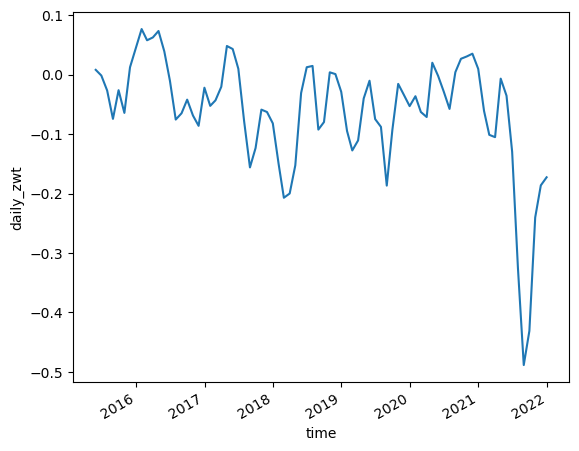

In [6]:
hr = xr.open_dataset(os.path.join(path_intrim, 'spruce_validation_data.nc'))
hr['daily_zwt'].resample(time = '1M').mean().mean(axis = 1).plot()